# AB Image Pair Description Generator

使用 GPT-5mini 为图片对生成变化描述和机器人指令

## 1. 参数配置

在这里配置所有需要的参数

In [ ]:
# =====================================================
# 参数配置区 - 请在这里修改参数
# =====================================================

# OpenAI API Key (必填)
OPENAI_API_KEY = ""

# OpenAI 模型 (gpt-4o, gpt-4o-mini 等)
MODEL = "gpt-5-mini"

# 输入目录，包含 pair_* 文件夹
INPUT_DIR = "/home/lican/workarea/Songwei/synthetic-data-examples/output/livingroom_move_origin/2_items"

# 最大输出 token 数
MAX_OUTPUT_TOKENS = 8000

## 2. 导入依赖和设置 API Key

In [12]:
import os
import base64
import json
import re
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

# 设置 API Key
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

from openai import OpenAI

print("依赖导入成功！")

依赖导入成功！


## 3. 数据结构和工具函数

In [13]:
@dataclass
class ObjectSpec:
    """对象规格：包含ID、像素坐标和世界坐标（世界坐标仅用于你在外部计算距离）"""
    object_id: str
    pixel_center_a: Tuple[int, int]
    pixel_center_b: Optional[Tuple[int, int]] = None
    world_coordinate_a: Optional[Tuple[float, float, float]] = None
    world_coordinate_b: Optional[Tuple[float, float, float]] = None
    move_distance_m: Optional[float] = None


def image_to_data_url(image_path: str) -> str:
    """
    将本地图片转换为 data URL，用于 OpenAI API。
    支持格式: PNG/JPEG/WEBP/GIF
    """
    p = Path(image_path)
    if not p.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    suffix = p.suffix.lower().lstrip(".")
    mime_map = {
        "png": "image/png",
        "jpg": "image/jpeg",
        "jpeg": "image/jpeg",
        "webp": "image/webp",
        "gif": "image/gif",
    }
    if suffix not in mime_map:
        raise ValueError(f"Unsupported image type: .{suffix}")

    b64 = base64.b64encode(p.read_bytes()).decode("utf-8")
    return f"data:{mime_map[suffix]};base64,{b64}"


def save_json(path: str, obj: Dict[str, Any]) -> None:
    """保存 JSON 文件"""
    Path(path).write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")


def _euclidean_distance_m(
    a: Tuple[float, float, float],
    b: Tuple[float, float, float],
) -> float:
    """计算 3D 欧氏距离（米）"""
    dx = a[0] - b[0]
    dy = a[1] - b[1]
    dz = a[2] - b[2]
    return math.sqrt(dx * dx + dy * dy + dz * dz)


def _format_distance_m(d: float, decimals: int = 2) -> str:
    """
    将距离格式化为英文自然语言：
    "moved about <distance> m"

    设计说明：
    - 距离数值由外部精确计算，这里只负责语言封装
    - 保留固定小数位，避免模型自行四舍五入或改写
    - 返回的是“可直接复述”的字符串，模型无需再加工
    """
    if d < 0:
        d = 0.0
    return f"moved about {d:.{decimals}f} m"

## 4. Prompt 构建

In [14]:
def build_prompt(objects: List[ObjectSpec], distance_decimals: int = 2) -> str:
    """
    构建用于多模态模型的 prompt（严格 JSON 输出），并强制模型：
    - 只用像素中心去“找物体”
    - 不输出任何坐标/像素/近似字样
    - 必须在 description 和 instruction 中都包含距离文本
    - 距离值由你提供或由世界坐标计算（但世界坐标不注入 prompt）
    """

    # 1) 构造 Target objects：用 JSON 风格块更稳定
    obj_entries: List[Dict[str, Any]] = []
    for o in objects:
        # 若没给 move_distance_m，但 world coords 都存在，则自动计算
        dist = o.move_distance_m
        if dist is None and (o.world_coordinate_a is not None and o.world_coordinate_b is not None):
            dist = _euclidean_distance_m(o.world_coordinate_a, o.world_coordinate_b)

        # 若仍缺失（例如对象只出现一张图、或没有世界坐标），默认 0
        # 这样才能满足“必须包含距离”的硬约束，避免模型胡编
        if dist is None:
            dist = 0.0

        entry: Dict[str, Any] = {
            "id": o.object_id,
            "pixel_center_A": [int(o.pixel_center_a[0]), int(o.pixel_center_a[1])],
            # 把距离直接给“自然语言字符串”，最稳：模型只需复述，不会重算/改写数值
            "movement_distance_text": _format_distance_m(dist, decimals=distance_decimals),
        }
        if o.pixel_center_b is not None:
            entry["pixel_center_B"] = [int(o.pixel_center_b[0]), int(o.pixel_center_b[1])]
        obj_entries.append(entry)

    # 2) 将对象列表渲染成 JSON-ish 文本（字段顺序稳定）
    obj_lines: List[str] = []
    for e in obj_entries:
        parts = [f'{{"id":"{e["id"]}","pixel_center_A":{e["pixel_center_A"]}']
        if "pixel_center_B" in e:
            parts.append(f',"pixel_center_B":{e["pixel_center_B"]}')
        parts.append(f',"movement_distance_text":"{e["movement_distance_text"]}"}}')
        obj_lines.append("  " + "".join(parts))
    obj_block = "[\n" + ",\n".join(obj_lines) + "\n]"

    # 3) Prompt：关键点
    # - 不注入 world_coordinate_A/B，避免模型泄漏/复述坐标
    # - 距离只用 movement_distance_text，并要求 verbatim
    return f"""
You are given two images of the same scene: Image A and Image B.

Image resolution: 1024 × 768.
Pixel coordinate system (for reference only):
- Origin (0, 0) is the top-left corner
- x increases to the right, y increases downward

You will receive a list of target objects with:
- pixel centers (ONLY for locating the correct objects), and
- a PRECOMPUTED movement distance text (movement_distance_text) that MUST be used verbatim.

CRITICAL CONSTRAINT (MUST FOLLOW):
- Do NOT include any pixel coordinates or numeric approximations of image location in your output.
- Do NOT write any of: "(x=..., y=...)", "x≈", "y≈", "pixel", "coordinate", "approx.", "approximately".
- Describe locations only using natural scene language (e.g., "left side of the counter", "near the stove", "next to the sink", "on the shelf").

DISTANCE REQUIREMENT (MUST FOLLOW):
- The ONLY numeric value allowed anywhere in the output is the movement distance contained inside movement_distance_text.
- You MUST include movement_distance_text verbatim in BOTH:
  (1) the change description, and
  (2) the robot instruction.
- Do NOT change the wording or the number in movement_distance_text.
- Do NOT add any other numbers.

Your tasks (for EACH target object):
1) Change description (A → B):
   - Describe how the object’s position changed in the camera view (left/right/up/down; closer/farther only if clearly inferable).
   - Describe any pose/orientation change (e.g., rotated, tilted, upright → fallen).
   - Include movement_distance_text verbatim.
   - If the object disappeared, is removed, or is fully occluded in B, state that explicitly.
   - You MAY use relative location to other scene objects ONLY if it makes the description significantly clearer.

2) Robot instruction:
   - Write one concise, physically reasonable instruction that would reproduce the change from A to B.
   - Include movement_distance_text verbatim.
   - Keep it minimal (no extra steps) and consistent with the described final position and pose.

OUTPUT FORMAT (STRICT):
- Return ONLY valid JSON. No markdown. No extra text.
- Do NOT omit any target object.
- The two lists must have the same length, and the i-th entries must correspond to the same object id.

JSON schema:
{{
  "description": [
    {{"id": "<object_id>", "text": "<change description>"}},
    ...
  ],
  "instructions": [
    {{"id": "<object_id>", "text": "<robot instruction>"}},
    ...
  ]
}}

Target objects:
{obj_block}
""".strip()

## 5. 响应解析和验证

In [15]:
def parse_model_output_to_json(text: str) -> Dict[str, Any]:
    """
    鲁棒的 JSON 解析器:
    1) 尝试直接解析
    2) 提取 {...} 块后解析
    3) 回退到旧格式解析
    """
    text = text.strip()

    # 1) 直接解析
    try:
        return json.loads(text)
    except Exception:
        pass

    # 2) 提取 JSON 对象
    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if m:
        try:
            return json.loads(m.group(0))
        except Exception:
            pass

    # 3) 回退解析旧格式
    desc_match = re.search(r"description\s*:\s*\[(.*?)\]", text, flags=re.DOTALL | re.IGNORECASE)
    inst_match = re.search(r"instructions\s*:\s*\[(.*?)\]", text, flags=re.DOTALL | re.IGNORECASE)
    if desc_match and inst_match:
        def _parse_list_body(body: str) -> List[str]:
            return re.findall(r"\"(.*?)\"", body, flags=re.DOTALL)

        desc_list = _parse_list_body(desc_match.group(1))
        inst_list = _parse_list_body(inst_match.group(1))
        return {
            "description": [{"id": str(i), "text": t} for i, t in enumerate(desc_list)],
            "instructions": [{"id": str(i), "text": t} for i, t in enumerate(inst_list)],
            "_warning": "Parsed legacy format; IDs are enumerated, not the original object IDs."
        }

    raise ValueError("Failed to parse model output as JSON. Raw text:\n" + text)


def validate_result(result: Dict[str, Any], object_ids: List[str]) -> None:
    """
    验证结果是否包含所有对象。
    """
    desc = result.get("description", [])
    inst = result.get("instructions", [])
    if not isinstance(desc, list) or not isinstance(inst, list):
        raise ValueError("JSON schema error: 'description' and 'instructions' must be lists.")

    if len(desc) != len(inst):
        raise ValueError("JSON schema error: 'description' and 'instructions' length mismatch.")

    got_ids_desc = [x.get("id") for x in desc if isinstance(x, dict)]
    got_ids_inst = [x.get("id") for x in inst if isinstance(x, dict)]
    if got_ids_desc != got_ids_inst:
        raise ValueError("Order/ID mismatch between description and instructions.")

    missing = [oid for oid in object_ids if oid not in got_ids_desc]
    if missing:
        raise ValueError(f"Missing objects in output: {missing}")


print("解析和验证函数定义完成！")

解析和验证函数定义完成！


## 6. OpenAI API 调用

In [16]:
def run_ab_diff(
    image_a_path: str,
    image_b_path: str,
    objects: List[ObjectSpec],
    model: str = "gpt-4o-mini",
    max_output_tokens: int = 800,
) -> Dict[str, Any]:
    """
    使用 OpenAI Chat Completions API 处理图片对。
    推荐模型: gpt-4o, gpt-4o-mini
    """
    client = OpenAI()

    prompt = build_prompt(objects)
    img_a = image_to_data_url(image_a_path)
    img_b = image_to_data_url(image_b_path)

    # 构建消息内容
    content = [
        {"type": "text", "text": prompt},
        {"type": "text", "text": "Image A:"},
        {"type": "image_url", "image_url": {"url": img_a}},
        {"type": "text", "text": "Image B:"},
        {"type": "image_url", "image_url": {"url": img_b}},
    ]

    resp = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": content,
            }
        ],
        max_completion_tokens=max_output_tokens,
    )

    # 提取响应文本
    text = resp.choices[0].message.content
    result = parse_model_output_to_json(text)

    object_ids = [o.object_id for o in objects]
    validate_result(result, object_ids)
    return result


print("API 调用函数定义完成！")

API 调用函数定义完成！


## 7. Metadata 读取和批量处理

In [17]:
def load_objects_from_metadata(metadata_path: str) -> List[ObjectSpec]:
    """
    从 metadata.json 中读取对象坐标信息。
    只返回 pixel_center_A/pixel_center_B 和 world_coordinate_A/world_coordinate_B 都不为 null 的对象，并计算直线距离（米）。
    """
    data = json.loads(Path(metadata_path).read_text(encoding="utf-8"))
    coordinates = data.get("coordinates", {})
    
    out: List[ObjectSpec] = []
    for obj_id, coords in coordinates.items():
        pixel_a = coords.get("pixel_center_A")
        pixel_b = coords.get("pixel_center_B")
        world_a = coords.get("world_coordinate_A")
        world_b = coords.get("world_coordinate_B")
        
        # 跳过缺少必要坐标的对象
        if pixel_a is None or pixel_b is None or world_a is None or world_b is None:
            continue
        
        distance_m = float(f"{math.dist(world_a, world_b):.4f}")
        
        # 使用对象路径的最后一部分作为简短 ID
        short_id = obj_id.split("/")[-1]
        out.append(ObjectSpec(
            object_id=short_id,
            pixel_center_a=tuple(pixel_a),
            pixel_center_b=tuple(pixel_b),
            world_coordinate_a=tuple(world_a),
            world_coordinate_b=tuple(world_b),
            move_distance_m=distance_m
        ))
    
    return out


def process_pair_folder(
    pair_folder: str,
    model: str = "gpt-4o-mini",
    max_output_tokens: int = 800,
) -> Optional[Dict[str, Any]]:
    """
    处理单个 pair 文件夹，生成描述并保存 result.json。
    """
    pair_path = Path(pair_folder)

    # 已生成过则直接跳过
    output_file = pair_path / "result.json"
    if output_file.exists():
        print(f"  [SKIP] Existing result.json in {pair_folder}")
        return None
    
    # 检查必要文件是否存在
    image_a = pair_path / "A_rgb.png"
    image_b = pair_path / "B_rgb.png"
    metadata_file = pair_path / "metadata.json"
    
    if not image_a.exists():
        print(f"  [SKIP] Missing A_rgb.png in {pair_folder}")
        return None
    if not image_b.exists():
        print(f"  [SKIP] Missing B_rgb.png in {pair_folder}")
        return None
    if not metadata_file.exists():
        print(f"  [SKIP] Missing metadata.json in {pair_folder}")
        return None
    
    # 从 metadata.json 加载对象
    objects = load_objects_from_metadata(str(metadata_file))
    
    if not objects:
        print(f"  [SKIP] No valid objects with pixel/world coordinates in {pair_folder}")
        return None
    
    print(f"  Found {len(objects)} objects with valid pixel/world coordinates: {[o.object_id for o in objects]}")
    
    # 调用 API 生成描述
    result = run_ab_diff(
        image_a_path=str(image_a),
        image_b_path=str(image_b),
        objects=objects,
        model=model,
        max_output_tokens=max_output_tokens,
    )
    
    # 保存结果
    output_file = pair_path / "result.json"
    save_json(str(output_file), result)
    print(f"  [OK] Saved: {output_file}")
    
    return result


def _find_pair_folders(input_path: Path) -> List[Path]:
    """在 input_path 下查找所有 pair_* 文件夹。

    兼容两种目录结构：
    - input_path/pair_0000/
    - input_path/<split>/pair_0000/（例如 0-19、20-39 等）
    """

    # 1) 先尝试当前目录的直接子目录（最快）
    direct = sorted([d for d in input_path.iterdir() if d.is_dir() and d.name.startswith("pair_")])
    if direct:
        return direct

    # 2) 否则递归查找（支持更上一级目录）
    return sorted([p for p in input_path.rglob("pair_*") if p.is_dir()])


def process_all_pairs(
    input_dir: str,
    model: str = "gpt-4o-mini",
    max_output_tokens: int = 800,
) -> Dict[str, Any]:
    """遍历 input_dir 下所有 pair_* 文件夹并处理（支持多层目录）。"""
    input_path = Path(input_dir)

    if not input_path.is_dir():
        raise ValueError(f"Input directory does not exist: {input_dir}")

    pair_folders = _find_pair_folders(input_path)

    if not pair_folders:
        print(f"No pair_* folders found under: {input_dir}")
        return {"total": 0, "success": 0, "skipped": 0, "failed": 0}

    print(f"Found {len(pair_folders)} pair folders to process")
    print("-" * 50)

    stats = {"total": len(pair_folders), "success": 0, "skipped": 0, "failed": 0}

    for i, pair_folder in enumerate(pair_folders, 1):
        # 用相对路径打印，便于看出属于哪个子目录
        try:
            rel = str(pair_folder.relative_to(input_path))
        except Exception:
            rel = pair_folder.name

        print(f"\n[{i}/{len(pair_folders)}] Processing: {rel}")
        try:
            result = process_pair_folder(
                str(pair_folder),
                model=model,
                max_output_tokens=max_output_tokens,
            )
            if result is not None:
                stats["success"] += 1
            else:
                stats["skipped"] += 1
        except Exception as e:
            print(f"  [ERROR] Failed: {e}")
            stats["failed"] += 1

    print("\n" + "=" * 50)
    print("Processing complete!")
    print(f"  Total: {stats['total']}")
    print(f"  Success: {stats['success']}")
    print(f"  Skipped: {stats['skipped']}")
    print(f"  Failed: {stats['failed']}")

    return stats


print("批量处理函数定义完成！")

批量处理函数定义完成！


## 8. 执行批量处理

运行下面的单元格开始处理所有图片对

In [18]:
# 开始处理！
stats = process_all_pairs(
    input_dir=INPUT_DIR,
    model=MODEL,
    max_output_tokens=MAX_OUTPUT_TOKENS,
)

Found 120 pair folders to process
--------------------------------------------------

[1/120] Processing: pair_0000
  Found 2 objects with valid pixel/world coordinates: ['TV_box_0000', 'vase_0020']
  [OK] Saved: /home/lican/workarea/Songwei/synthetic-data-examples/output/livingroom_move_origin/2_items/pair_0000/result.json

[2/120] Processing: pair_0001
  Found 2 objects with valid pixel/world coordinates: ['vase_0019', 'plate_0000']
  [OK] Saved: /home/lican/workarea/Songwei/synthetic-data-examples/output/livingroom_move_origin/2_items/pair_0001/result.json

[3/120] Processing: pair_0002
  Found 2 objects with valid pixel/world coordinates: ['book_0029', 'plate_0000']
  [OK] Saved: /home/lican/workarea/Songwei/synthetic-data-examples/output/livingroom_move_origin/2_items/pair_0002/result.json

[4/120] Processing: pair_0003
  Found 2 objects with valid pixel/world coordinates: ['vase_0020', 'book_0029']
  [OK] Saved: /home/lican/workarea/Songwei/synthetic-data-examples/output/livingro

## 9. 查看结果示例（可选）

In [19]:
# 查看第一个处理成功的结果
from IPython.display import JSON, display

input_path = Path(INPUT_DIR)
pair_folders = sorted([d for d in input_path.iterdir() if d.is_dir() and d.name.startswith("pair_")])

for pair_folder in pair_folders:
    result_file = pair_folder / "result.json"
    if result_file.exists():
        print(f"Result from: {pair_folder.name}")
        result = json.loads(result_file.read_text(encoding="utf-8"))
        display(JSON(result))
        break
else:
    print("No result.json files found.")

Result from: pair_0000


<IPython.core.display.JSON object>

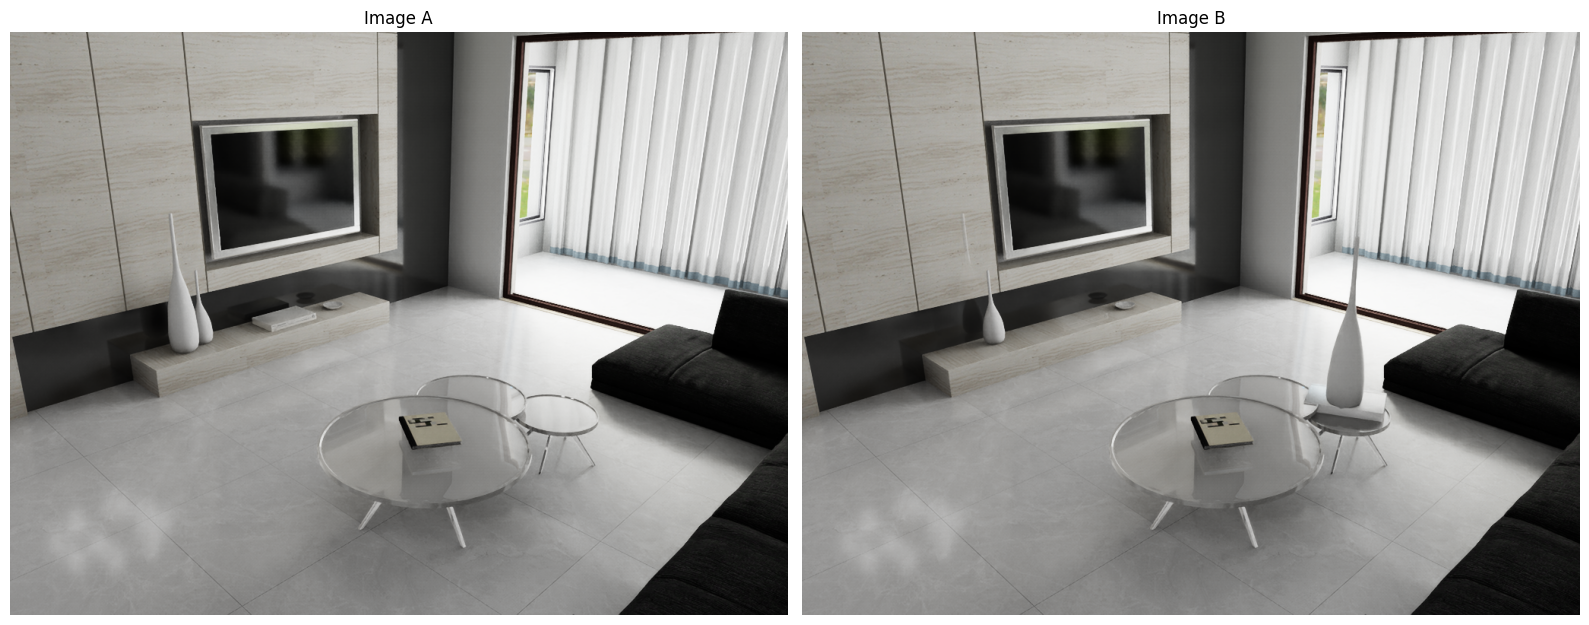

In [20]:
# 显示图片对（可选）
from IPython.display import Image, display
import matplotlib.pyplot as plt

if pair_folders:
    first_pair = pair_folders[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    img_a = plt.imread(first_pair / "A_rgb.png")
    img_b = plt.imread(first_pair / "B_rgb.png")
    
    axes[0].imshow(img_a)
    axes[0].set_title("Image A")
    axes[0].axis("off")
    
    axes[1].imshow(img_b)
    axes[1].set_title("Image B")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()